Example code for "Efficient second-harmonic generation of quasi-bound states in the continuum in lithium niobate thin film enhanced by Bloch surface waves
".

[1]Y. Lin et al., “Efficient second-harmonic Generation of quasi-bound States in the Continuum in Lithium Niobate Thin Film Enhanced by Bloch Surface Waves,” Nanophotonics, vol. 0, no. 0, Mar. 2024, doi: https://doi.org/10.1515/nanoph-2023-0886.

In [1]:
import pandas as pd
import numpy as np
from inkstone import Inkstone
from matplotlib import pyplot as plt

In [2]:
# Function to set up materials. The refractive index is represented using equation. It can also be read from a dataset.
def setup_materials(s, wavelength):
    n_LiNbO3 = (1 + 2.6734 / (1 - 0.01764 / wavelength**2) + 1.2290 / (1 - 0.05914 / wavelength**2) + 12.614 / (1 - 474.60 / wavelength**2))**0.5
    n_SiO2 = (1 + 0.6961663 / (1 - (0.0684043 / wavelength)**2) + 0.4079426 / (1 - (0.1162414 / wavelength)**2) + 0.8974794 / (1 - (9.896161 / wavelength)**2))**0.5
    n_Si3N4 = (1 + 3.0249 / (1 - (0.1353406 / wavelength)**2) + 40314 / (1 - (1239.842 / wavelength)**2))**0.5

    s.AddMaterial(name='LiNbO3', epsilon=n_LiNbO3**2)
    s.AddMaterial(name='SiO2', epsilon=n_SiO2**2)
    s.AddMaterial(name='Si3N4', epsilon=n_Si3N4**2)

# Function to set up in different configurations
def setup_layers(s, config_type='default'):
    s.AddLayer(name='in', thickness=0, material_background='vacuum')

    if config_type == 'default':
        for i in range(1, 19):
            material = 'SiO2' if i % 2 == 1 else 'Si3N4'
            thickness = 0.14 if i % 2 == 1 else 0.1
            s.AddLayer(name=str(i), thickness=thickness, material_background=material)
    elif config_type == 'waveguide':
        s.AddLayer(name='WG', thickness=0.2, material_background='LiNbO3')
        for i in range(1, 19):
            material = 'SiO2' if i % 2 == 1 else 'Si3N4'
            thickness = 0.14 if i % 2 == 1 else 0.1
            s.AddLayer(name=str(i), thickness=thickness, material_background=material)
    elif config_type == 'grating':
        s.AddLayer(name='grating', thickness=0.08, material_background='SiO2')
        s.AddPattern1D(layer='grating', pattern_name='box', material='vacuum', width=0.132, center=0.134)
        s.AddPattern1D(layer='grating', pattern_name='box', material='vacuum', width=0.108, center=0.334)
        s.AddLayer(name='WG', thickness=0.2, material_background='LiNbO3')
        for i in range(1, 19):
            material = 'SiO2' if i % 2 == 1 else 'Si3N4'
            thickness = 0.14 if i % 2 == 1 else 0.1
            s.AddLayer(name=str(i), thickness=thickness, material_background=material)

    s.AddLayerCopy(name='out', original_layer='in', thickness=0)

# Function to calculate reflection and transmission
def calculate_spectrum(wavelength_range, config_type='default'):
    flux_in = []
    flux_out = []
    for wavelength in wavelength_range:
        freq = 1 / wavelength
        s = Inkstone()
        s.lattice = 0.4
        s.num_g = 30

        # Setup materials and structure
        setup_materials(s, wavelength)
        setup_layers(s, config_type)

        # Set excitation
        s.SetExcitation(theta=-0.1, phi=0, s_amplitude=1, p_amplitude=0)
        s.SetFrequency(freq)

        print(f'Wavelength: {wavelength:g}')

        # Calculate power flux
        flux_in.append(s.GetPowerFlux('in'))
        flux_out.append(s.GetPowerFlux('out'))

    # Calculate reflection and transmission
    incident = np.array([a[0] for a in flux_in])
    reflection = -np.array([a[1] for a in flux_in]) / incident
    transmission = np.array([a[0] for a in flux_out]) / incident

    return reflection, transmission

# Define wavelength range
wavelength = np.linspace(0.5, 0.9, 101)

# Example: Default configuration
reflection1, transmission1 = calculate_spectrum(wavelength, config_type='default')

# Example: Waveguide configuration
reflection2, transmission2 = calculate_spectrum(wavelength, config_type='waveguide')

# Example: Grating configuration
reflection3, transmission3 = calculate_spectrum(wavelength, config_type='grating')

Wavelength: 0.5
Wavelength: 0.504
Wavelength: 0.508
Wavelength: 0.512
Wavelength: 0.516
Wavelength: 0.52
Wavelength: 0.524
Wavelength: 0.528
Wavelength: 0.532
Wavelength: 0.536
Wavelength: 0.54
Wavelength: 0.544
Wavelength: 0.548
Wavelength: 0.552
Wavelength: 0.556
Wavelength: 0.56
Wavelength: 0.564
Wavelength: 0.568
Wavelength: 0.572
Wavelength: 0.576
Wavelength: 0.58
Wavelength: 0.584
Wavelength: 0.588
Wavelength: 0.592
Wavelength: 0.596
Wavelength: 0.6
Wavelength: 0.604
Wavelength: 0.608
Wavelength: 0.612
Wavelength: 0.616
Wavelength: 0.62
Wavelength: 0.624
Wavelength: 0.628
Wavelength: 0.632
Wavelength: 0.636
Wavelength: 0.64
Wavelength: 0.644
Wavelength: 0.648
Wavelength: 0.652
Wavelength: 0.656
Wavelength: 0.66
Wavelength: 0.664
Wavelength: 0.668
Wavelength: 0.672
Wavelength: 0.676
Wavelength: 0.68
Wavelength: 0.684
Wavelength: 0.688
Wavelength: 0.692
Wavelength: 0.696
Wavelength: 0.7
Wavelength: 0.704
Wavelength: 0.708
Wavelength: 0.712
Wavelength: 0.716
Wavelength: 0.72
Wavelen

/Users/arthurzhao/Desktop/inkstone/inkstone/layer.py:270: UserWarning: A box with this name already exists in this layer. The existing box will be overridden.
  warn('A box with this name already exists in this layer. The existing box will be overridden.', UserWarning)


Wavelength: 0.5
Wavelength: 0.504
Wavelength: 0.508
Wavelength: 0.512
Wavelength: 0.516
Wavelength: 0.52
Wavelength: 0.524
Wavelength: 0.528
Wavelength: 0.532
Wavelength: 0.536
Wavelength: 0.54
Wavelength: 0.544
Wavelength: 0.548
Wavelength: 0.552
Wavelength: 0.556
Wavelength: 0.56
Wavelength: 0.564
Wavelength: 0.568
Wavelength: 0.572
Wavelength: 0.576
Wavelength: 0.58
Wavelength: 0.584
Wavelength: 0.588
Wavelength: 0.592
Wavelength: 0.596
Wavelength: 0.6
Wavelength: 0.604
Wavelength: 0.608
Wavelength: 0.612
Wavelength: 0.616
Wavelength: 0.62
Wavelength: 0.624
Wavelength: 0.628
Wavelength: 0.632
Wavelength: 0.636
Wavelength: 0.64
Wavelength: 0.644
Wavelength: 0.648
Wavelength: 0.652
Wavelength: 0.656
Wavelength: 0.66
Wavelength: 0.664
Wavelength: 0.668
Wavelength: 0.672
Wavelength: 0.676
Wavelength: 0.68
Wavelength: 0.684
Wavelength: 0.688
Wavelength: 0.692
Wavelength: 0.696
Wavelength: 0.7
Wavelength: 0.704
Wavelength: 0.708
Wavelength: 0.712
Wavelength: 0.716
Wavelength: 0.72
Wavelen

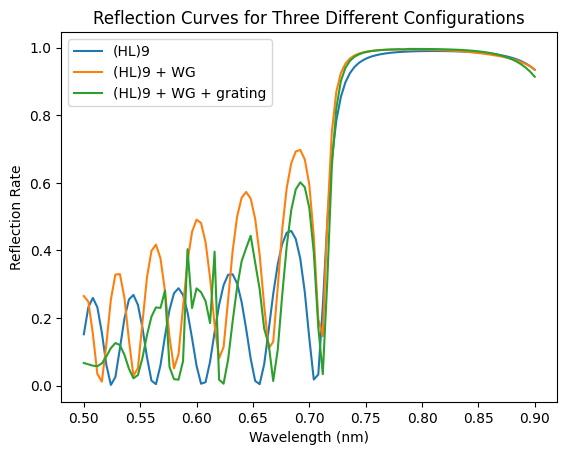

In [3]:
#%% plotting
plt.plot(wavelength, reflection1, label='(HL)9')
plt.plot(wavelength, reflection2, label='(HL)9 + WG')
plt.plot(wavelength, reflection3, label='(HL)9 + WG + grating')
plt.xlabel('Wavelength (nm)')
plt.ylabel('Reflection Rate')
plt.title('Reflection Curves for Three Different Configurations')
plt.legend()
plt.show()